# Trabajo Práctico N.º 2 — Embeddings y búsqueda semántica

**Procesamiento de Lenguaje Natural · TUIA · UNR**

**Integrantes:** Josías Calabozo · Sharo Giuntoli · Ismael Darruiz · Sebastián Di Carlo

**Corpus:** los 200 libros de la categoría "Los más comentados" de Lectulandia, extraídos en el TP1 (`../P1/data/libros.csv`).

| Parte | Tema | Estado |
|---|---|---|
| 0 | Primer análisis del corpus | ✅ |
| A | Corpus en dos versiones | ✅ |
| — | Línea de base TF-IDF y funciones de búsqueda | ✅ |
| B | Word2Vec propio contra SBW | ✅ |
| C | Modelo de oración (SBERT) | ✅ |
| D | Comparación y visualización | ⏳ Falta el ranking por consultas (necesita `queries.json`) |
| 5 | Evaluación con precision@k | ⏳ Necesita `queries.json` |
| E, F | Persistencia en pgvector y búsqueda en SQL | ⏳ Fase 2: cuando se vea pgvector en clase |
| 6 | Parte avanzada | ⏳ A definir |

**Cómo ejecutarlo:** kernel `Python 3.12 (PLN TP2)`, con `P2/` como carpeta de trabajo. El modelo SBW (~1 GB) va en `models/` y se baja de [SBWCE](https://cs.famaf.unc.edu.ar/~ccardellino/SBWCE/SBW-vectors-300-min5.bin.gz); `distiluse` lo baja `sentence-transformers` la primera vez. En Colab: clonar el repo del grupo, entrar a `P2/` y bajar SBW con `!wget`, como en el apunte de la Unidad 2.

In [1]:
import os
import re
import json
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"   # aviso de la caché de Hugging Face en Windows
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

SEMILLA = 42
RUTA_CORPUS = "../P1/data/libros.csv"
RUTA_SBW = "models/SBW-vectors-300-min5.bin.gz"
RUTA_QUERIES = "queries.json"
os.makedirs("data", exist_ok=True)   # acá se guardan los embeddings (ignorados por git)

---
# Parte 0 — Primer análisis del corpus

Antes de representar el texto, miramos qué tenemos y respondemos las cuatro preguntas que plantea el enunciado al comienzo de la sección 4:

1. ¿Cuántas sinopsis hacen falta para que los términos característicos de TF-IDF sean estables? ¿Cómo medirlo?
2. ¿Qué sesgo introduce que las sinopsis sean texto **promocional**?
3. ¿Cómo cambia la evaluación si la clasificación es **multi-etiqueta**?
4. ¿Hay libros en gallego o catalán? ¿Hace falta detectar el idioma antes de tokenizar?

> El enunciado habla de "12 documentos": ese bloque parece venir de otro material. Nuestro corpus tiene 200 libros, y respondemos con esos datos.

In [2]:
libros = pd.read_csv(RUTA_CORPUS)
libros["lista_generos"] = libros["generos"].str.split(r"\s*\|\s*")   # "Drama | Novela" → ["Drama", "Novela"]
libros["n_palabras"] = libros["sinopsis"].str.split().str.len()

print(f"{len(libros)} libros, {libros.shape[1]} columnas")
libros[["titulo", "autores", "generos", "serie", "n_palabras"]].head()

200 libros, 15 columnas


,titulo,autores,generos,serie,n_palabras
0,La chica del tren,Paula Hawkins,Intriga | Novela | Policíaco,NaN,115
1,El libro negro de la Nueva Izquierda,Agustín Laje | Nicolás Márquez,Ciencias sociales | Ensayo,NaN,366
2,Ready Player One,Ernest Cline,Ciencia ficción,NaN,186
3,It,Stephen King,Terror,NaN,142
4,La verdad sobre el caso Harry Quebert,Joël Dicker,Novela | Policíaco,Marcus Goldman,144


Libros según cantidad de géneros: {1: 31, 2: 103, 3: 56, 4: 9, 5: 1}
Listas de géneros en orden alfabético: 100%


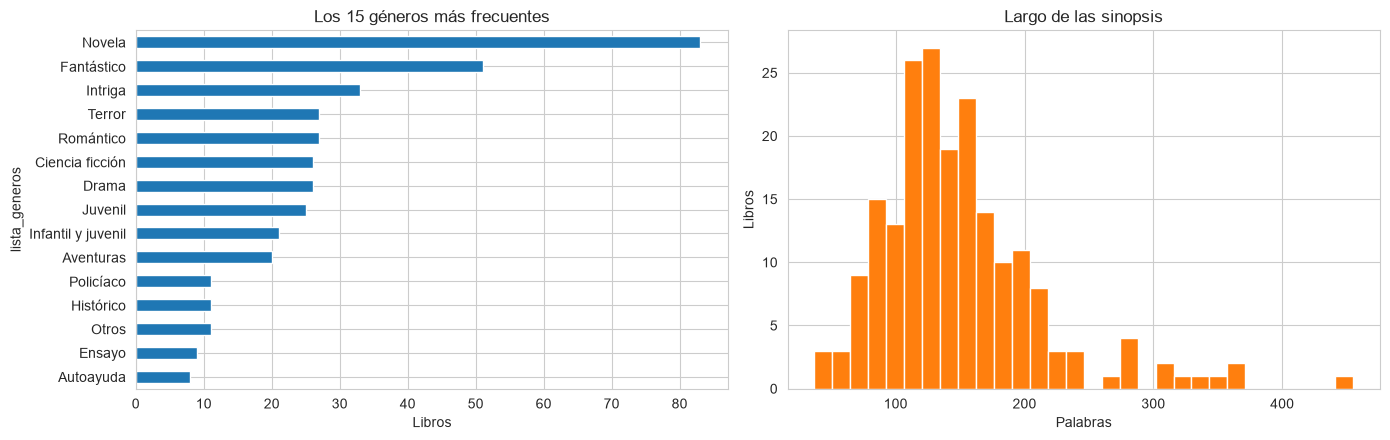

count    200.0
mean     149.0
std       63.0
min       37.0
25%      111.0
50%      136.0
75%      174.0
max      455.0


In [3]:
# Géneros: cada libro puede tener varios
n_generos = libros["lista_generos"].str.len()
print("Libros según cantidad de géneros:", n_generos.value_counts().sort_index().to_dict())

# ¿En qué orden vienen? Si vienen ordenados alfabéticamente, "el primer género" no significa nada
en_orden = libros["lista_generos"].apply(lambda generos: generos == sorted(generos))
print(f"Listas de géneros en orden alfabético: {en_orden.mean():.0%}")

frecuencia_generos = libros["lista_generos"].explode().value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
frecuencia_generos.head(15)[::-1].plot.barh(ax=axes[0], color="tab:blue")
axes[0].set(title="Los 15 géneros más frecuentes", xlabel="Libros")
libros["n_palabras"].plot.hist(bins=30, ax=axes[1], color="tab:orange")
axes[1].set(title="Largo de las sinopsis", xlabel="Palabras", ylabel="Libros")
plt.tight_layout()
plt.show()
print(libros["n_palabras"].describe().round(0).to_string())

In [4]:
# Series y libros repetidos
print(f"Libros que pertenecen a una serie: {libros['serie'].notna().sum()} (en {libros['serie'].nunique()} series)")
print(f"Autores con más libros: {libros['autores'].value_counts().head(4).to_dict()}")

# Mismo libro con otro título o edición (encontrados al revisar el listado del corpus)
REPETIDOS = [
    ("1984", "1984 (Trad. Miguel Temprano García)"),
    ("Cien años de soledad (Edición conmemorativa)", "Cien años de soledad (Ed. Ilustrada)"),
    ("Rebelión en la granja", "Rebelión en la granja (trad. Marcial Souto y Miguel Temprano García)"),
    ("El imperio final", "El Imperio Final. (Ed. revisada)"),
    ("Sapiens", "De animales a dioses"),
]
titulos = set(libros["titulo"])
assert all(a in titulos and b in titulos for a, b in REPETIDOS)
print(f"\nPares de libros repetidos: {len(REPETIDOS)}")

Libros que pertenecen a una serie: 89 (en 67 series)
Autores con más libros: {'Stephen King': 12, 'Brandon Sanderson': 9, 'Sarah J. Maas': 5, 'J. K. Rowling': 5}

Pares de libros repetidos: 5


**Qué vemos en el corpus**

- **169 de los 200 libros (85 %) tienen más de un género**, y las listas vienen **ordenadas alfabéticamente** en el 100 % de los casos. El primer género de la lista no es "el principal", así que no lo usamos como etiqueta.
- **"Novela" aparece en 83 libros:** es un formato más que un tema. Además conviven etiquetas redundantes, como "Juvenil" e "Infantil y juvenil".
- **Las sinopsis son cortas:** entre 37 y 455 palabras, con una mediana de 136. Eso limita a TF-IDF y a un Word2Vec entrenado con este corpus.
- **Hay sagas y autores muy representados:** 89 libros pertenecen a una serie, y Stephen King (12) y Brandon Sanderson (9) concentran muchos títulos. "Parecido" puede terminar significando "del mismo autor o de la misma saga".
- **Cinco libros están repetidos** con otro título o en otra edición. Los dejamos: es el corpus que entregó el TP1, y nos sirven como prueba en la Parte D. En `queries.json`, si una edición es relevante, la otra también.

### Pregunta 1 — ¿Cuántas sinopsis hacen falta para que TF-IDF sea estable?

**Cómo lo medimos.** Los "términos característicos" de una sinopsis son sus 10 palabras con mayor TF-IDF (desempatando por orden alfabético, ver abajo). Como el IDF depende del corpus, esas palabras cambian según con cuántos documentos se calcule. Para cada tamaño `n`:

1. tomamos `n` sinopsis al azar (20 repeticiones);
2. calculamos TF-IDF solo con esas `n`;
3. comparamos los 10 términos de cada sinopsis con los que obtiene usando el corpus completo, con la **similitud de Jaccard** (Unidad 3): intersección sobre unión de los dos conjuntos.

Si los términos fueran estables, el Jaccard sería cercano a 1 con pocos documentos.

Sinopsis donde la 10.ª palabra empata con otras que quedan afuera del top: 88%
Palabras con el mismo peso que la 10.ª (mediana): 17



     Jaccard medio  desvío
n                         
12           0.561   0.204
25           0.589   0.202
50           0.659   0.198
100          0.782   0.169
150          0.880   0.135


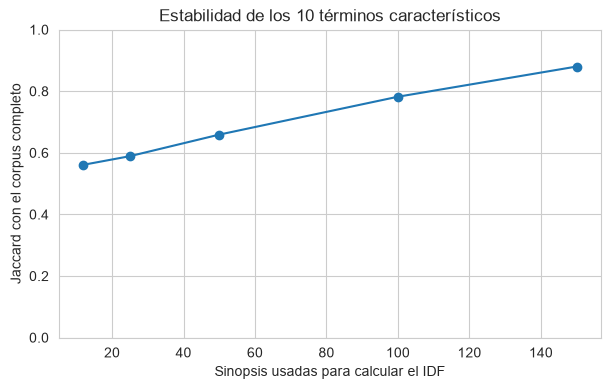

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords", quiet=True)
STOPWORDS = set(stopwords.words("spanish"))


def top_terminos(textos, k=10):
    """Los k términos con mayor TF-IDF de cada texto, calculando el IDF solo con esos textos."""
    vectorizador = TfidfVectorizer(stop_words=list(STOPWORDS))
    X = vectorizador.fit_transform(textos)
    vocabulario = vectorizador.get_feature_names_out()
    tops = []
    for fila in X:   # una fila (sparse) por documento
        pesos = fila.toarray().ravel()
        presentes = np.nonzero(pesos)[0]
        # Muchas palabras empatan (las que aparecen una vez en la sinopsis y en ningún otro libro).
        # Se desempata por orden alfabético: si no, el top dependería del azar del ordenamiento.
        orden = sorted(presentes, key=lambda j: (-pesos[j], vocabulario[j]))
        tops.append(set(vocabulario[orden[:k]]))
    return tops


def jaccard(a, b):
    return len(a & b) / len(a | b)


sinopsis = libros["sinopsis"].tolist()
referencia = top_terminos(sinopsis)   # con el corpus completo (200)

# ¿Cuántas palabras empatan con la que queda 10.ª? (con el corpus completo)
X_completo = TfidfVectorizer(stop_words=list(STOPWORDS)).fit_transform(sinopsis)
hay_empate_afuera, empatadas = [], []
for fila in X_completo:
    pesos = np.sort(fila.toarray().ravel())[::-1]   # de mayor a menor
    iguales_al_10 = np.isclose(pesos, pesos[9])
    empatadas.append(iguales_al_10.sum())
    hay_empate_afuera.append(iguales_al_10[10:].any())   # alguna empatada quedó fuera del top 10
print(f"Sinopsis donde la 10.ª palabra empata con otras que quedan afuera del top: {np.mean(hay_empate_afuera):.0%}")
print(f"Palabras con el mismo peso que la 10.ª (mediana): {np.median(empatadas):.0f}\n")

rng = np.random.default_rng(SEMILLA)
resultados = []
for n in [12, 25, 50, 100, 150]:
    for _ in range(20):
        muestra = rng.choice(len(sinopsis), size=n, replace=False)
        tops = top_terminos([sinopsis[i] for i in muestra])
        for i, top in zip(muestra, tops):
            resultados.append({"n": n, "jaccard": jaccard(top, referencia[i])})

estabilidad = pd.DataFrame(resultados).groupby("n")["jaccard"].agg(["mean", "std"]).round(3)
print(estabilidad.rename(columns={"mean": "Jaccard medio", "std": "desvío"}).to_string())

ax = estabilidad["mean"].plot(marker="o", figsize=(7, 4))
ax.set(xlabel="Sinopsis usadas para calcular el IDF", ylabel="Jaccard con el corpus completo",
       title="Estabilidad de los 10 términos característicos", ylim=(0, 1))
plt.show()

**Respuesta**

- **Hay muchísimos empates.** En el **88 %** de las sinopsis, la palabra que queda 10.ª tiene el mismo peso que otras que quedan afuera del top (mediana: 17 palabras empatadas). Son las palabras que aparecen una vez en la sinopsis y en ningún otro libro: todas tienen el mismo TF y el mismo IDF. Sin un desempate fijo, el experimento mediría el azar del ordenamiento y no la estabilidad del IDF.
- **Con 12 sinopsis, el top 10 coincide a medias con el del corpus completo** (Jaccard 0,56). Con tan pocos documentos, casi cualquier palabra es "rara", y el IDF no distingue lo característico de lo casual: es lo que el enunciado llama "casi ruido".
- **La coincidencia crece con el tamaño** (0,66 con 50; 0,78 con 100; 0,88 con 150) **y no llega a estabilizarse** dentro de nuestro corpus.
- **¿Cuántas sinopsis harían falta?** Con 200 no lo podemos responder con certeza, porque la curva sigue subiendo. Con más datos, se mediría igual: agregar documentos hasta que el Jaccard entre corridas sucesivas se mantenga alto (por ejemplo, por encima de 0,9).
- **Limitación del método:** la referencia es el corpus de 200, que tampoco es "la verdad". Además, una muestra de 150 comparte tres cuartos de los documentos con la referencia, así que su Jaccard sale alto en parte por eso.

### Pregunta 2 — Sesgo de las sinopsis promocionales

Las sinopsis de Lectulandia son contratapas: están escritas para **vender** el libro, no para describirlo. Buscamos expresiones típicas de marketing.

In [6]:
EXPRESIONES_PROMOCIONALES = ["éxito", "best seller", "bestseller", "millones de", "premio", "fenómeno",
                             "imprescindible", "aclamad", "obra maestra", "lectores", "traducid",
                             "saga", "adaptación", "película", "serie de"]

texto_minusculas = libros["sinopsis"].str.lower()
conteo = {expresion: texto_minusculas.str.contains(expresion, regex=False).sum()
          for expresion in EXPRESIONES_PROMOCIONALES}
promocional = pd.Series(conteo).sort_values(ascending=False)
print("Libros cuya sinopsis contiene cada expresión:")
print(promocional[promocional > 0].to_string())

con_alguna = texto_minusculas.apply(lambda t: any(e in t for e in EXPRESIONES_PROMOCIONALES))
print(f"\nSinopsis con al menos una expresión promocional: {con_alguna.sum()} de {len(libros)}")

Libros cuya sinopsis contiene cada expresión:
millones de       14
éxito             11
premio             8
lectores           7
saga               5
serie de           5
fenómeno           4
best seller        3
obra maestra       3
traducid           2
aclamad            2
película           2
imprescindible     1
adaptación         1

Sinopsis con al menos una expresión promocional: 52 de 200


**Respuesta**

- **52 de las 200 sinopsis (26 %)** tienen al menos una expresión de marketing: "millones de" (14), "éxito" (11), "premio" (8), "lectores" (7). Es una cota aproximada: algunas coincidencias no son promocionales ("millones de años").
- **El sesgo:** una sinopsis promocional describe cómo se vende el libro, no solo de qué trata. Exagera el tono, omite el final y repite fórmulas comerciales. Un clasificador de género aprendería también esas fórmulas: si un género se vende con cierto tipo de frase, el modelo aprende la frase y no el contenido.
- **Para la búsqueda:** una consulta que use ese vocabulario ("un libro exitoso", "un fenómeno") va a encontrar libros por cómo se promocionan, no por de qué tratan.

### Pregunta 3 — Multi-etiqueta

In [7]:
# Pares de géneros que aparecen juntos en un mismo libro
pares = Counter()
for generos in libros["lista_generos"]:
    for i in range(len(generos)):
        for j in range(i + 1, len(generos)):
            pares[(generos[i], generos[j])] += 1

print(f"Libros con más de un género: {(n_generos > 1).sum()} de {len(libros)}")
print("\nPares de géneros más frecuentes:")
for (a, b), n in pares.most_common(8):
    print(f"  {n:>3}  {a} + {b}")

Libros con más de un género: 169 de 200

Pares de géneros más frecuentes:
   24  Fantástico + Novela
   19  Juvenil + Novela
   18  Novela + Romántico
   14  Intriga + Novela
   13  Fantástico + Juvenil
   11  Aventuras + Fantástico
   11  Fantástico + Infantil y juvenil
   10  Drama + Novela


**Respuesta**

- **169 libros tienen más de un género.** Los pares más frecuentes combinan un tema con "Novela" (Fantástico + Novela, 24) o géneros afines (Fantástico + Juvenil, 13).
- **Cómo cambia la evaluación.** En multi-clase, cada libro tiene una sola respuesta correcta y la accuracy cuenta aciertos exactos. En multi-etiqueta, una predicción puede ser **parcialmente correcta**: acertar 2 de 3 géneros.
  - Exigir el conjunto exacto de géneros es demasiado estricto.
  - Se evalúa **por etiqueta**: precisión y recall de cada género por separado, y después se promedian.
- **Para este TP:** afecta la proyección 2D (por eso hacemos un panel por género) y el clustering de la parte avanzada. Un clustering duro asigna un solo grupo por libro, y no puede representar un libro que es fantástico y juvenil a la vez.

### Pregunta 4 — ¿Hay sinopsis en otros idiomas?

Usamos `langdetect` (Unidad 3), que compara n-gramas de caracteres con perfiles de cada idioma. Fijamos la semilla porque el algoritmo tiene una parte aleatoria.

In [8]:
from langdetect import detect, DetectorFactory

DetectorFactory.seed = 0   # sin esto, dos corridas pueden dar resultados distintos
libros["idioma"] = libros["sinopsis"].apply(detect)
print("Idioma detectado:", libros["idioma"].value_counts().to_dict())
libros.loc[libros["idioma"] != "es", ["titulo", "idioma", "sinopsis"]]

Idioma detectado: {'es': 200}


,titulo,idioma,sinopsis


**Respuesta**

- `langdetect` clasifica las **200 sinopsis como español**. En nuestro corpus no hay libros en gallego ni en catalán: la pregunta del enunciado parece venir de otro corpus.
- **¿Hace falta detectar el idioma antes de tokenizar?** En general, sí. Las stopwords, el tokenizador y SBW son de español, y un texto en catalán quedaría casi entero fuera del vocabulario, con un vector de documento pobre o inexistente. En este corpus no cambia nada, pero dejamos la verificación: es barata y evita sorpresas si se agregan libros.

### Decisiones de preprocesamiento: qué se pierde en cada una

Cada paso de limpieza es una **pérdida de información deliberada**, y conviene o no según el modelo que reciba el texto:

| Decisión | Qué se pierde | ¿La aplicamos? |
|---|---|---|
| Pasar a minúsculas | Nombres propios y entidades (`Madrid` contra `madrid`, `Harry`) | Sí para TF-IDF y Word2Vec propio. **No** para SBW (distingue mayúsculas: tiene `Harry` pero no `harry`) ni para SBERT |
| Sacar tildes | `si`/`sí`, `el`/`él`, `esta`/`está` | **No.** SBW tiene las palabras con tilde, y sacarlas las dejaría fuera de su vocabulario |
| Sacar puntuación y números | Límites de oración, años, cantidades | Sí para TF-IDF y Word2Vec. **No** para SBERT |
| Sacar stopwords | Negaciones ("no"), relaciones ("sin", "contra") | Sí para TF-IDF y para promediar word vectors. **No** para SBERT, que usa las palabras funcionales para entender la oración |

---
# Parte A — El corpus en dos versiones

- **Cruda:** el texto natural, solo con los espacios normalizados. Es para el modelo de oración, que fue entrenado sobre texto real y usa el orden y las palabras funcionales.
- **Limpia:** tokenizada, sin puntuación, sin números y sin stopwords. Es para TF-IDF y Word2Vec, que solo ven bolsas de palabras.

**El preprocesamiento pertenece al modelo, no al corpus:** la limpieza que ayuda a TF-IDF destruye información que el modelo de oración necesita.

In [9]:
def tokenizar(texto, minusculas=True):
    """Lista de palabras del texto, sin puntuación ni números."""
    if minusculas:
        texto = texto.lower()
    # [^\W\d_]+ = una o más letras. Excluye lo que no es letra ni número (\W), los dígitos (\d)
    # y el guion bajo. Así se conservan las tildes y la ñ.
    return re.findall(r"[^\W\d_]+", texto)


def sin_stopwords(palabras):
    return [p for p in palabras if p.lower() not in STOPWORDS]


libros["texto_crudo"] = libros["sinopsis"].str.replace(r"\s+", " ", regex=True).str.strip()
libros["tokens"] = libros["texto_crudo"].apply(lambda t: sin_stopwords(tokenizar(t)))
libros["texto_limpio"] = libros["tokens"].str.join(" ")
# Para SBW: misma limpieza, pero sin pasar a minúsculas
libros["tokens_mayusculas"] = libros["texto_crudo"].apply(lambda t: sin_stopwords(tokenizar(t, minusculas=False)))

ejemplo = libros.loc[libros["titulo"] == "Harry Potter y la piedra filosofal"].iloc[0]
print("CRUDA:  ", ejemplo["texto_crudo"][:300], "…")
print("\nLIMPIA: ", ejemplo["texto_limpio"][:300], "…")
print("\nPARA SBW:", " ".join(ejemplo["tokens_mayusculas"])[:300], "…")

palabras_crudas = libros["texto_crudo"].apply(lambda t: len(tokenizar(t))).sum()
palabras_limpias = libros["tokens"].str.len().sum()
print(f"\nPalabras en total: {palabras_crudas:,} → {palabras_limpias:,} sin stopwords "
      f"({1 - palabras_limpias / palabras_crudas:.0%} menos)")
print(f"Vocabulario de la versión limpia: {libros['tokens'].explode().nunique():,} palabras distintas")

CRUDA:   Harry Potter se ha quedado huérfano y vive en casa de sus abominables tíos y del insoportable primo Dudley. Harry se siente muy triste y solo, hasta que un buen día recibe una carta que cambiará su vida para siempre. En ella le comunican que ha sido aceptado como alumno en el colegio interno Hogwart …

LIMPIA:  harry potter quedado huérfano vive casa abominables tíos insoportable primo dudley harry triste solo buen día recibe carta cambiará vida siempre comunican sido aceptado alumno colegio interno hogwarts magia hechicería partir momento suerte harry da vuelco espectacular escuela tan especial aprenderá  …

PARA SBW: Harry Potter quedado huérfano vive casa abominables tíos insoportable primo Dudley Harry triste solo buen día recibe carta cambiará vida siempre comunican sido aceptado alumno colegio interno Hogwarts magia hechicería partir momento suerte Harry da vuelco espectacular escuela tan especial aprenderá  …

Palabras en total: 29,684 → 15,327 sin stopwords (48% menos)

**Qué muestra**

- Sacar stopwords elimina el **48 %** de las palabras (de 29.684 a 15.327): casi la mitad del texto son palabras funcionales. Para TF-IDF son ruido; para SBERT, son parte de la estructura de la oración.
- El vocabulario limpio tiene **6.647 palabras distintas**, y el 63 % aparece una sola vez (ver la Parte B).
- En el ejemplo de *Harry Potter* se ve la diferencia entre las versiones: la limpia pierde las mayúsculas ("harry", "hogwarts"), que SBW necesita para reconocer nombres propios. Por eso la versión para SBW las conserva.

| Representación | Recibe |
|---|---|
| TF-IDF (línea de base) | `texto_limpio` |
| Word2Vec propio | `tokens` |
| SBW (promedio) | `tokens_mayusculas` |
| SBERT | `texto_crudo` |

---
# Línea de base TF-IDF y funciones de búsqueda

El enunciado compara contra "el TF-IDF del TP1", pero el TP1 fue solo el scraper: la línea de base la construimos acá.

Para comparar los modelos de forma pareja, todos se usan igual: **cada libro es un vector normalizado** (norma 1), una consulta se convierte en un vector del mismo espacio, y la similitud es el **coseno**. Con vectores de norma 1, el coseno es simplemente el producto punto.

> En la **fase 2**, `buscar()` va a resolver la similitud en SQL con pgvector. Por ahora, la resuelve numpy.

In [10]:
from sklearn.preprocessing import normalize

tfidf = TfidfVectorizer(sublinear_tf=True)   # el texto ya viene limpio
X_tfidf = tfidf.fit_transform(libros["texto_limpio"])   # TfidfVectorizer ya normaliza cada fila (norma L2)
print(f"TF-IDF: {X_tfidf.shape[0]} libros × {X_tfidf.shape[1]:,} términos")


def vector_consulta_tfidf(consulta):
    return tfidf.transform([" ".join(sin_stopwords(tokenizar(consulta)))])


# Cada modelo se registra con su matriz de libros y su forma de vectorizar una consulta
MODELOS = {"TF-IDF": {"matriz": X_tfidf, "consulta": vector_consulta_tfidf}}


def buscar(consulta, modelo, k=5, genero=None):
    """Los k libros más parecidos a la consulta según el modelo, con filtro opcional por género."""
    m = MODELOS[modelo]
    q = m["consulta"](consulta)
    if hasattr(q, "toarray"):   # TF-IDF devuelve matrices sparse
        scores = (m["matriz"] @ q.T).toarray().ravel()
    else:                       # los demás modelos, vectores de numpy
        scores = m["matriz"] @ q
    resultado = libros[["titulo", "autores", "generos"]].copy()
    resultado["score"] = scores
    if genero is not None:
        resultado = resultado[libros["lista_generos"].apply(lambda generos: genero in generos)]
    return resultado.sort_values("score", ascending=False).head(k)

TF-IDF: 200 libros × 6,635 términos


---
# Parte B — Word2Vec propio contra SBW

## B.1 Word2Vec entrenado con nuestro corpus

| Parámetro | Valor | Por qué |
|---|---|---|
| `vector_size` | 100 | Con ~16 mil palabras de entrenamiento no hay datos para llenar muchas dimensiones; el apunte también usa 100 |
| `window` | 5 | Contexto de 5 palabras a cada lado: suficiente para capturar el tema en sinopsis ya sin stopwords |
| `min_count` | 2 | El 63 % del vocabulario aparece una sola vez. Una palabra vista una vez tiene un único contexto, y su vector sería ruido |
| `sg` | 1 (skip-gram) | Skip-gram aprende mejor las palabras poco frecuentes, que en un corpus chico son casi todas. CBOW promedia el contexto y favorece las frecuentes |
| `negative` | 5 | **Negative sampling:** en vez de calcular un softmax sobre todo el vocabulario en cada paso, el modelo aprende a distinguir el par (palabra, contexto) real de 5 pares con palabras al azar. Es lo que hace viable el entrenamiento |
| `epochs` | 50 | Con tan pocos datos, las 5 pasadas por defecto no alcanzan |
| `workers`, `seed` | 1, 42 | Un solo hilo y una semilla fija hacen que el resultado sea reproducible |

In [11]:
from gensim.models import Word2Vec

w2v = Word2Vec(sentences=libros["tokens"].tolist(), vector_size=100, window=5, min_count=2,
               sg=1, negative=5, epochs=50, workers=1, seed=SEMILLA)
print(f"Word2Vec propio: {len(w2v.wv):,} palabras en el vocabulario, {w2v.wv.vector_size} dimensiones")

Word2Vec propio: 2,449 palabras en el vocabulario, 100 dimensiones


## B.2 SBW pre-entrenado (Spanish Billion Word Corpus)

Se carga como en el apunte de la Unidad 2. Tarda alrededor de un minuto y ocupa ~1,2 GB de memoria.

In [12]:
from gensim.models import KeyedVectors

sbw = KeyedVectors.load_word2vec_format(RUTA_SBW, binary=True)
print(f"SBW: {len(sbw):,} palabras en el vocabulario, {sbw.vector_size} dimensiones")

SBW: 1,000,653 palabras en el vocabulario, 300 dimensiones


## B.3 Vecinos más cercanos, lado a lado

In [13]:
PALABRAS = ["amor", "muerte", "familia", "magia", "guerra", "asesino"]


def vecinos(kv, palabra, n=6):
    if palabra not in kv.key_to_index:
        return ["(no está en el vocabulario)"]
    return [f"{p} ({s:.2f})" for p, s in kv.most_similar(palabra, topn=n)]


for palabra in PALABRAS:
    tabla = pd.DataFrame({"Word2Vec propio": vecinos(w2v.wv, palabra), "SBW": vecinos(sbw, palabra)})
    print(f"\n«{palabra}»  (aparece {libros['tokens'].explode().eq(palabra).sum()} veces en el corpus)")
    print(tabla.to_string(index=False))


«amor»  (aparece 48 veces en el corpus)
   Word2Vec propio            SBW
  prohibido (0.74) desamor (0.76)
 coloniales (0.68)    amar (0.73)
  prohibida (0.68) ternura (0.71)
  compasión (0.67)  pasión (0.69)
  desengaño (0.66)   amada (0.69)
excepcional (0.65)    fati (0.68)

«muerte»  (aparece 37 veces en el corpus)
    Word2Vec propio                  SBW
       jesús (0.61) fallecimiento (0.77)
   anunciada (0.59)     asesinato (0.69)
veinticuatro (0.58)         morir (0.66)
      luchar (0.58)       muriera (0.65)
       txato (0.58)         murió (0.65)
        pelo (0.57)        muerto (0.65)

«familia»  (aparece 32 veces en el corpus)
  Word2Vec propio                  SBW
florentino (0.69)      cavicola (0.66)
  miembros (0.66)    Bochicidae (0.66)
   recibir (0.65)      Cornufer (0.66)
abnegación (0.65)        Eburia (0.66)
  nogueira (0.64)  Ideoroncidae (0.66)
   comidas (0.63) Pomatiopsidae (0.66)



«magia»  (aparece 14 veces en el corpus)
    Word2Vec propio             SBW
  hechicería (0.84)   mágico (0.70)
     vuelven (0.81)     mago (0.70)
   alomancia (0.78)  potagia (0.70)
inquisidores (0.77) hechizos (0.69)
    hogwarts (0.77)  mágicas (0.69)
     temores (0.76)    magos (0.69)

«guerra»  (aparece 14 veces en el corpus)
 Word2Vec propio                   SBW
  kaladin (0.75)         Guerra (0.74)
quebradas (0.73)        guerras (0.69)
inminente (0.72) francoprusiana (0.64)
 llanuras (0.69)         bélica (0.64)
radiantes (0.68)        batalla (0.64)
  mundial (0.68)        cruenta (0.64)

«asesino»  (aparece 12 veces en el corpus)
Word2Vec propio              SBW
   serie (0.76)  homicida (0.75)
 apuntan (0.74) psicópata (0.73)
   terry (0.68)   asesina (0.72)
llevarán (0.68)  asesinos (0.71)
    daño (0.65)  violador (0.70)
resuelto (0.64) pistolero (0.68)


**Word2Vec propio: aprende de qué libro viene la palabra, no qué significa**

- Los vecinos de *guerra* (*kaladin*, *quebradas*, *radiantes*, *llanuras*) aparecen solo en los dos libros de la saga de Sanderson (*El camino de los reyes* y *Palabras radiantes*).
- Los de *magia* mezclan Harry Potter (*hogwarts*) y *Nacidos de la bruma* (*alomancia*, *inquisidores*).
- Los de *muerte* incluyen *anunciada* (de *Crónica de una muerte anunciada*), *txato* (de *Patria*) y *jesús* (de *Jerusalén*).
- **Por qué:** dos palabras "se parecen" si comparten contexto, y con ~15 mil palabras de entrenamiento la mayoría aparece en uno o dos libros. En este corpus, compartir contexto casi siempre significa **estar en la misma sinopsis**. Las similitudes altas (0,6 a 0,8) no indican calidad: son vecinos por co-ocurrencia.

**SBW: vecinos semánticos, pero con el sesgo de su propio corpus**

- *amor* → *desamor, amar, ternura, pasión*; *muerte* → *fallecimiento, asesinato, morir*; *asesino* → *homicida, psicópata*. Son relaciones de significado, aprendidas de más de mil millones de palabras.
- Pero *familia* → *Bochicidae, Cornufer, Eburia*: **familias biológicas**. En los textos con que se entrenó SBW, que incluyen la Wikipedia en español, "familia" aparece muchísimo en descripciones de especies ("pertenece a la familia…"). El modelo refleja su corpus de entrenamiento, no el nuestro.
- También hay ruido de mayúsculas (*Guerra* como vecino de *guerra*) y rarezas (*fati*, por "amor fati").

**Conclusión:** para el vector de documento conviene SBW. Un Word2Vec propio necesitaría muchísimos más datos que 200 sinopsis.

## B.4 Vector de documento: el promedio de sus palabras

El vector de cada libro es el promedio de los vectores de sus palabras (las que estén en el vocabulario del modelo).

**Qué se pierde al promediar:**
- **El orden:** "el perro mordió al hombre" y "el hombre mordió al perro" dan el mismo vector. El apunte lo muestra con spaCy: *"this is cool"* e *"is this cool"* tienen similitud 1,0.
- **Las negaciones y los modificadores:** "no" ya se fue con las stopwords; y aunque quedara, su vector se diluye entre las demás palabras.
- **El peso relativo:** una palabra central para el libro pesa lo mismo que una accesoria. En sinopsis largas, el promedio tiende al "vector promedio del idioma" y los libros se parecen todos entre sí.
- **Las palabras fuera del vocabulario:** simplemente no cuentan.

**Por qué lo usamos igual:** es simple, rápido y no necesita entrenar nada más. Además, es la línea de base natural para medir cuánto aporta un modelo de oración.

In [14]:
def vector_promedio(palabras, kv, probar_minusculas=False):
    """Promedio de los vectores de las palabras que el modelo conoce.
    Devuelve None si no conoce ninguna: ahí el promedio no existe."""
    vectores = []
    for p in palabras:
        if p in kv.key_to_index:
            vectores.append(kv[p])
        elif probar_minusculas and p.lower() in kv.key_to_index:   # "Dragón" al empezar la oración
            vectores.append(kv[p.lower()])
    if not vectores:
        return None
    return np.mean(vectores, axis=0)


def matriz_de_documentos(columna_tokens, kv, probar_minusculas=False):
    """Una fila normalizada por libro. Los libros sin ninguna palabra conocida quedan en cero."""
    filas, sin_vector = [], 0
    for palabras in libros[columna_tokens]:
        v = vector_promedio(palabras, kv, probar_minusculas)
        if v is None:
            sin_vector += 1
            v = np.zeros(kv.vector_size)
        filas.append(v)
    M = np.array(filas)
    assert np.isfinite(M).all()   # ningún NaN ni infinito (lo pide la parte E)
    return normalize(M), sin_vector   # normalize deja las filas en cero tal como están


def cobertura(columna_tokens, kv, probar_minusculas=False):
    """Proporción de palabras del corpus que el modelo conoce."""
    palabras = libros[columna_tokens].explode().dropna()
    conocidas = palabras.apply(lambda p: p in kv.key_to_index
                               or (probar_minusculas and p.lower() in kv.key_to_index))
    return conocidas.mean()


X_w2v, sin_vector_w2v = matriz_de_documentos("tokens", w2v.wv)
X_sbw, sin_vector_sbw = matriz_de_documentos("tokens_mayusculas", sbw, probar_minusculas=True)

print(f"Word2Vec propio: conoce el {cobertura('tokens', w2v.wv):.0%} de las palabras; libros sin vector: {sin_vector_w2v}")
print(f"SBW:             conoce el {cobertura('tokens_mayusculas', sbw, True):.0%} de las palabras; libros sin vector: {sin_vector_sbw}")


def vector_consulta_promedio(kv, minusculas, probar_minusculas):
    def vectorizar(consulta):
        v = vector_promedio(sin_stopwords(tokenizar(consulta, minusculas)), kv, probar_minusculas)
        return np.zeros(kv.vector_size) if v is None else v / np.linalg.norm(v)
    return vectorizar


MODELOS["W2V propio"] = {"matriz": X_w2v, "consulta": vector_consulta_promedio(w2v.wv, True, False)}
MODELOS["SBW"] = {"matriz": X_sbw, "consulta": vector_consulta_promedio(sbw, False, True)}

Word2Vec propio: conoce el 73% de las palabras; libros sin vector: 0
SBW:             conoce el 99% de las palabras; libros sin vector: 0


**Qué muestra**

- **Cobertura:** el Word2Vec propio conoce el **73 %** de las palabras del corpus; las que aparecen una sola vez quedaron afuera por `min_count=2`. SBW conoce el **99 %**, en parte porque prueba en minúsculas las palabras con mayúscula inicial.
- **Ningún libro quedó sin vector.** Igual dejamos el control (`np.isfinite` y la fila en cero), porque es lo que la parte E pide manejar antes de insertar en la base: con un texto corto o lleno de palabras raras, el promedio podría no existir.
- El costo de promediar se ve en la Parte D: con SBW, dos libros al azar se parecen 0,87 en promedio.

---
# Parte C — Modelo de oración: SBERT

Usamos `distiluse-base-multilingual-cased-v1`, el modelo de la Unidad 2. Recibe el **texto crudo**.

In [15]:
from sentence_transformers import SentenceTransformer

sbert = SentenceTransformer("distiluse-base-multilingual-cased-v1")
dimension = sbert.encode(["prueba"]).shape[1]
print(f"Dimensión: {dimension}")
print(f"Límite de tokens (max_seq_length): {sbert.max_seq_length}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1241.43it/s]

Dimensión: 512
Límite de tokens (max_seq_length): 128


### ¿Cuántas sinopsis se truncan?

El modelo **no avisa** cuando un texto supera el límite: corta los tokens que sobran y sigue. Para saberlo, hay que tokenizar cada sinopsis con el mismo tokenizador del modelo y contar. Se suman 2 tokens especiales, `[CLS]` y `[SEP]`, que el modelo agrega al principio y al final.

Ojo: un token no es una palabra. El tokenizador parte las palabras poco comunes en pedazos (por ejemplo, `bucaneros` → `bu`, `##can`, `##eros`).

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (166 > 128). Running this sequence through the model will result in indexing errors


Sinopsis truncadas: 178 de 200 (89%)
Tokens por sinopsis: mediana 200, máximo 715
En las truncadas, el modelo no ve en promedio el 39% final del texto


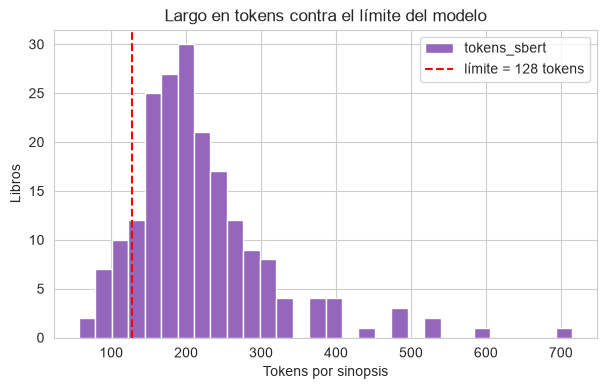

In [16]:
libros["tokens_sbert"] = libros["texto_crudo"].apply(lambda t: len(sbert.tokenizer.tokenize(t)) + 2)
limite = sbert.max_seq_length
truncados = libros["tokens_sbert"] > limite

print(f"Sinopsis truncadas: {truncados.sum()} de {len(libros)} ({truncados.mean():.0%})")
print(f"Tokens por sinopsis: mediana {libros['tokens_sbert'].median():.0f}, máximo {libros['tokens_sbert'].max()}")
perdido = ((libros["tokens_sbert"] - limite).clip(lower=0) / libros["tokens_sbert"])[truncados]
print(f"En las truncadas, el modelo no ve en promedio el {perdido.mean():.0%} final del texto")

ax = libros["tokens_sbert"].plot.hist(bins=30, figsize=(7, 4), color="tab:purple")
ax.axvline(limite, color="red", ls="--", label=f"límite = {limite} tokens")
ax.set(xlabel="Tokens por sinopsis", ylabel="Libros", title="Largo en tokens contra el límite del modelo")
ax.legend()
plt.show()

**Qué muestra**

- **178 de las 200 sinopsis (89 %) superan los 128 tokens** y se truncan sin aviso. En esas, el modelo **no ve en promedio el 39 % final del texto**.
- La sinopsis mediana tiene 200 tokens, aunque solo 136 palabras. El tokenizador parte las palabras poco frecuentes en varios pedazos, y con un vocabulario multilingüe eso pasa seguido en español.
- **Consecuencia:** el embedding de casi todo el corpus representa solo el comienzo de la sinopsis. Si lo que define a un libro aparece al final (un giro de la trama, "una novela de terror…"), el modelo no lo ve. Es la motivación de la parte avanzada de *chunking*: partir la sinopsis y guardar varios vectores por libro.

In [17]:
# Embeddings normalizados (norma 1) de las 200 sinopsis, guardados en disco para no recalcularlos
RUTA_EMB_SBERT = "data/embeddings_sbert.npy"
if os.path.exists(RUTA_EMB_SBERT):
    X_sbert = np.load(RUTA_EMB_SBERT)
else:
    X_sbert = sbert.encode(libros["texto_crudo"].tolist(), normalize_embeddings=True, show_progress_bar=False)
    np.save(RUTA_EMB_SBERT, X_sbert)
assert np.isfinite(X_sbert).all()
print(f"SBERT: {X_sbert.shape[0]} libros × {X_sbert.shape[1]} dimensiones")

MODELOS["SBERT"] = {"matriz": X_sbert,
                    "consulta": lambda consulta: sbert.encode(consulta, normalize_embeddings=True)}

# Verificación de que buscar() funciona con los 4 modelos, sin mirar resultados:
# las consultas de evaluación se escriben antes de ver qué devuelve cada modelo
for nombre in MODELOS:
    assert len(buscar("una historia", nombre, k=3)) == 3
print("Modelos listos:", list(MODELOS))

SBERT: 200 libros × 512 dimensiones
Modelos listos: ['TF-IDF', 'W2V propio', 'SBW', 'SBERT']


---
# Parte D — Comparación y visualización

> El **ranking lado a lado para 3 consultas** queda para cuando tengamos `queries.json`: el enunciado pide escribir las consultas y sus libros relevantes **antes** de ver resultados.

## D.1 ¿Cuánto se parecen dos libros al azar?

Un espacio donde todo se parece a todo no discrimina, aunque el ranking igual devuelva resultados. Medimos la similitud entre 2.000 pares de libros elegidos al azar.

        TF-IDF  W2V propio    SBW  SBERT
media    0.016       0.708  0.874  0.221
desvío   0.014       0.077  0.039  0.092
mínimo   0.000       0.437  0.695  0.003
máximo   0.155       0.913  0.964  0.570


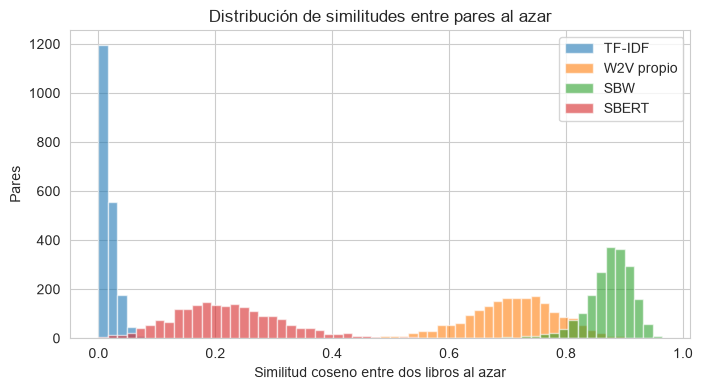

In [18]:
rng = np.random.default_rng(SEMILLA)
i = rng.integers(0, len(libros), 2000)
j = rng.integers(0, len(libros), 2000)
distintos = i != j
i, j = i[distintos], j[distintos]


def similitudes_al_azar(X):
    """Coseno entre los pares (i, j). Con filas de norma 1, es el producto punto fila a fila."""
    if hasattr(X, "toarray"):
        X = X.toarray()
    return np.sum(X[i] * X[j], axis=1)


azar = pd.DataFrame({nombre: similitudes_al_azar(m["matriz"]) for nombre, m in MODELOS.items()})
print(azar.describe().loc[["mean", "std", "min", "max"]].round(3)
      .rename(index={"mean": "media", "std": "desvío", "min": "mínimo", "max": "máximo"}).to_string())

ax = azar.plot.hist(bins=60, alpha=0.6, figsize=(8, 4))
ax.set(xlabel="Similitud coseno entre dos libros al azar", ylabel="Pares",
       title="Distribución de similitudes entre pares al azar")
plt.show()

**Qué muestra**

| Modelo | Media | Desvío | Lectura |
|---|---|---|---|
| TF-IDF | 0,02 | 0,01 | Casi todos los pares son ortogonales: comparten pocas palabras. Discrimina, pero solo por coincidencia léxica |
| W2V propio | 0,71 | 0,08 | Todos los libros se parecen bastante entre sí |
| SBW | 0,87 | 0,04 | **Todo se parece a todo** (rango de 0,70 a 0,96). Promediar cientos de palabras lleva cada libro hacia el "vector promedio del español" |
| SBERT | 0,22 | 0,09 | El espacio más repartido: dos libros al azar se parecen poco, y queda margen para distinguir |

- **Importa el desvío, no la media.** Con SBW, la diferencia entre un libro muy parecido y uno cualquiera es de pocos centésimos. El ranking siempre devuelve algo, pero los puntajes casi no separan lo relevante de lo que no.
- **Los puntajes de distintos modelos no se comparan entre sí:** 0,85 es un valor "normal" en SBW, mientras que 0,57 es de lo más alto que se observa en SBERT.

## D.2 Prueba natural: ediciones del mismo libro

Cuatro de los pares repetidos tienen **sinopsis distintas** para el mismo libro. Si un modelo captura el significado, al buscar con la sinopsis de una edición la otra debería quedar entre las primeras. Medimos en qué puesto queda la otra edición entre los 199 libros restantes (1 = la más parecida).

In [19]:
indice = {titulo: n for n, titulo in enumerate(libros["titulo"])}


def puesto_del_gemelo(X, a, b):
    """Puesto de b cuando se ordenan todos los libros por similitud con a (sin contar a)."""
    if hasattr(X, "toarray"):
        X = X.toarray()
    sim = X @ X[indice[a]]
    sim[indice[a]] = -np.inf   # el propio libro no cuenta
    orden = np.argsort(-sim)
    return int(np.where(orden == indice[b])[0][0]) + 1


puestos = pd.DataFrame({nombre: [puesto_del_gemelo(m["matriz"], a, b) for a, b in REPETIDOS]
                        for nombre, m in MODELOS.items()},
                       index=[a[:30] for a, _ in REPETIDOS])
print(puestos.to_string())

                                TF-IDF  W2V propio  SBW  SBERT
1984                                 1         113    3      2
Cien años de soledad (Edición        1           1    1      1
Rebelión en la granja                1          17    4      1
El imperio final                     1           1    1      1
Sapiens                              1           1    1      1


**Qué muestra**

- **TF-IDF encuentra todas las ediciones en el puesto 1**, aunque las dos sinopsis de *1984* casi no comparten texto. Le alcanzan los nombres propios y las palabras raras: las dos dicen *Winston*, *Smith* y *Partido*, y las de *Rebelión en la granja* dicen *estalinismo*, *totalitarismo* y *sátira*. Una palabra rara compartida pesa muchísimo en TF-IDF. **Es un caso legítimo donde TF-IDF gana**, como anticipa el enunciado.
- **SBERT** pone las ediciones en los puestos 1 o 2, y **SBW** entre el 1 y el 4.
- **El Word2Vec propio falla con *1984*** (puesto 113). Con vectores pobres y promediados, dos textos distintos sobre el mismo libro no quedan cerca.
- *Sapiens*, *El imperio final* y *Cien años de soledad* salen primeros en todos los modelos: sus sinopsis son idénticas o comparten mucho texto, así que no son una prueba difícil.

## D.3 Proyección 2D

Como cada libro tiene varios géneros, en vez de elegir uno solo (y el primero es solo el primero en orden alfabético), hacemos **un panel por género**: los libros que lo tienen, en color, y el resto en gris. Proyectamos con PCA e informamos la varianza explicada.

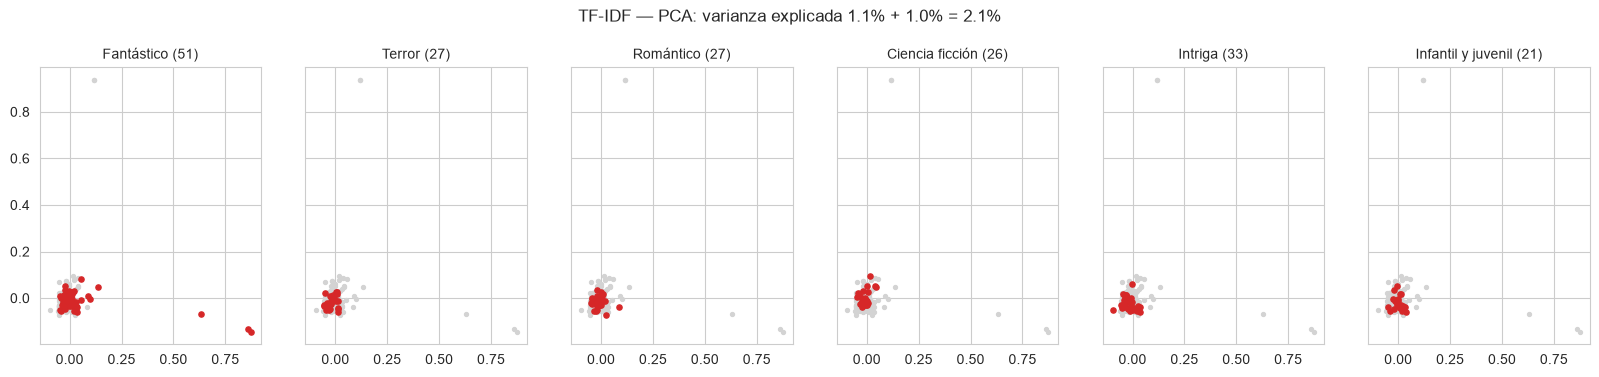

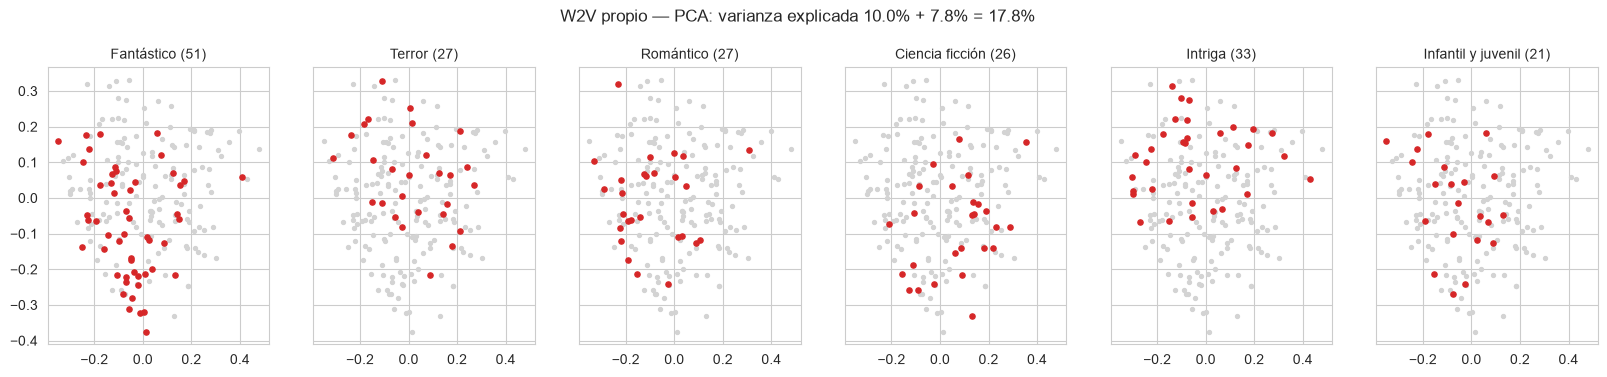

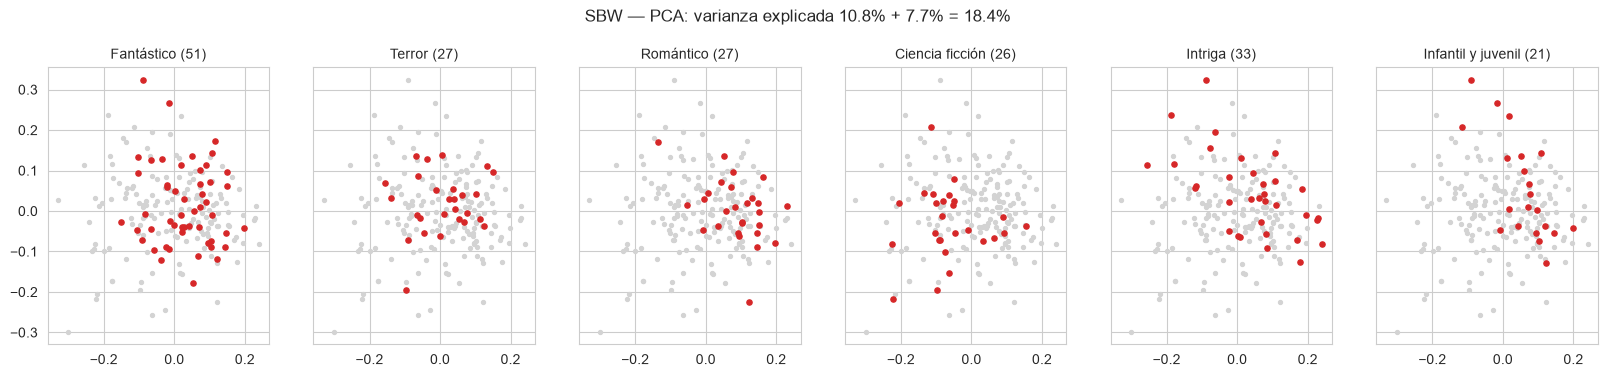

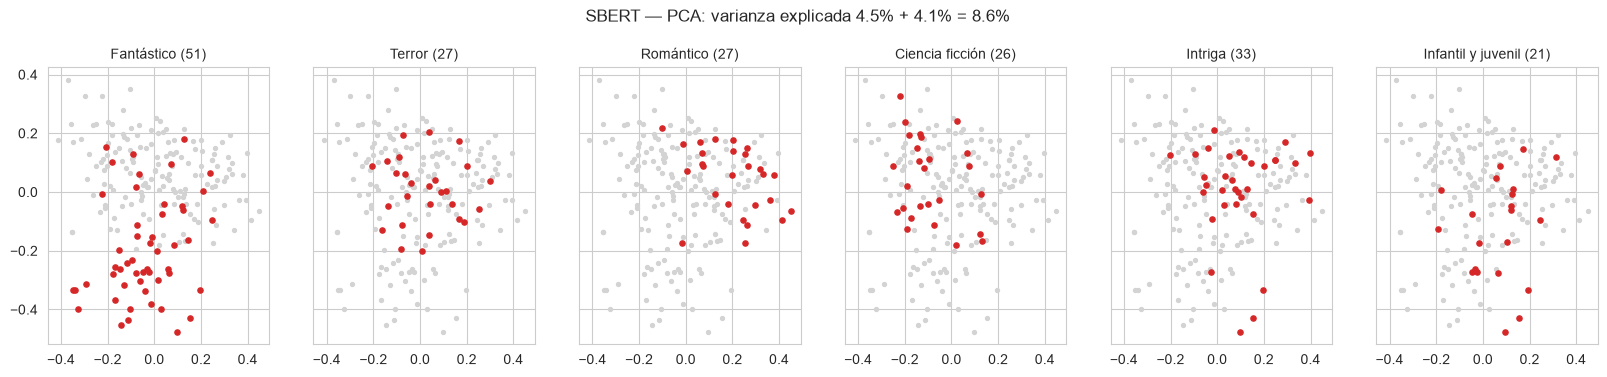

In [20]:
from sklearn.decomposition import PCA

GENEROS_PANEL = ["Fantástico", "Terror", "Romántico", "Ciencia ficción", "Intriga", "Infantil y juvenil"]


def paneles_por_genero(X, titulo):
    X = X.toarray() if hasattr(X, "toarray") else X
    pca = PCA(n_components=2, random_state=SEMILLA)
    X_2d = pca.fit_transform(X)
    var = pca.explained_variance_ratio_
    fig, axes = plt.subplots(1, len(GENEROS_PANEL), figsize=(20, 3.6), sharex=True, sharey=True)
    for ax, genero in zip(axes, GENEROS_PANEL):
        tiene = libros["lista_generos"].apply(lambda generos: genero in generos).to_numpy()
        ax.scatter(X_2d[~tiene, 0], X_2d[~tiene, 1], s=8, color="lightgray")
        ax.scatter(X_2d[tiene, 0], X_2d[tiene, 1], s=14, color="tab:red")
        ax.set_title(f"{genero} ({tiene.sum()})", fontsize=10)
    fig.suptitle(f"{titulo} — PCA: varianza explicada {var[0]:.1%} + {var[1]:.1%} = {var.sum():.1%}", y=1.04)
    plt.show()


for nombre, m in MODELOS.items():
    paneles_por_genero(m["matriz"], nombre)

**Qué muestra**

- **TF-IDF (2,1 % de varianza):** las dos componentes solo capturan **duplicados**. La primera separa a los tres libros de *Nacidos de la bruma*, que comparten el texto promocional de la saga; la segunda, a *Sapiens* y *De animales a dioses* (sinopsis idéntica: un solo punto). El resto queda amontonado. PCA busca la dirección de mayor varianza, y en TF-IDF la mayor varianza la producen los textos casi repetidos.
- **W2V propio (17,8 %) y SBW (18,4 %):** explican más varianza, pero los géneros se mezclan. En el Word2Vec propio, Fantástico tiende a quedar abajo, superpuesto con el resto. En SBW no hay regiones: es el "todo se parece a todo" de D.1.
- **SBERT (8,6 %):** es el único donde se ven regiones. **Fantástico** se concentra abajo a la izquierda, **Romántico** a la derecha y **Ciencia ficción** arriba a la izquierda. Terror e Intriga quedan más mezclados.

**Advertencia metodológica:** proyectar 512 dimensiones (o 6.635, en TF-IDF) sobre 2 descarta casi toda la información: más del 80 % de la varianza no se ve en ningún caso. Una nube mezclada en 2D puede estar separada en el espacio original. Y explicar más varianza (como SBW) no significa separar mejor los géneros.

---
# Parte 5 — Evaluación con precision@k

> ⏳ **Pendiente de `queries.json`.** Las funciones están listas; la evaluación corre cuando el archivo exista.

- **precision@k:** de los `k` libros que devuelve el modelo, qué proporción es relevante.
- **Piso de azar:** un ranking al azar acierta, en promedio, `relevantes / 200` en cada posición. Una consulta con 50 libros relevantes tiene un piso de 0,25 y casi cualquier modelo la "aprueba": **toda métrica necesita su línea de base**.
- Formato de `queries.json`: una lista de objetos `{"id", "consulta", "relevantes": [títulos exactos], "tipo"}`.

In [21]:
K = 5


def precision_at_k(recuperados, relevantes, k=K):
    return len(set(recuperados[:k]) & set(relevantes)) / k


def validar_queries(queries):
    """Revisa que los títulos existan y que las dos ediciones de un libro repetido vayan juntas."""
    problemas = []
    for q in queries:
        for t in q["relevantes"]:
            if t not in titulos:
                problemas.append(f"{q['id']}: «{t}» no está en el corpus")
        for a, b in REPETIDOS:
            if (a in q["relevantes"]) != (b in q["relevantes"]):
                problemas.append(f"{q['id']}: tiene solo una edición de «{a}»")
    return problemas


def evaluar(queries, k=K):
    filas = []
    for q in queries:
        fila = {"id": q["id"], "consulta": q["consulta"], "relevantes": len(q["relevantes"]),
                "azar": len(q["relevantes"]) / len(libros)}
        for nombre in MODELOS:
            recuperados = buscar(q["consulta"], nombre, k=k)["titulo"].tolist()
            fila[nombre] = precision_at_k(recuperados, q["relevantes"], k)
        filas.append(fila)
    return pd.DataFrame(filas)


if os.path.exists(RUTA_QUERIES):
    queries = json.load(open(RUTA_QUERIES, encoding="utf-8"))
    problemas = validar_queries(queries)
    print("\n".join(problemas) if problemas else f"{len(queries)} consultas válidas")
else:
    print(f"Todavía no existe {RUTA_QUERIES}: la evaluación queda pendiente.")

Todavía no existe queries.json: la evaluación queda pendiente.


---
# Partes E y F — Persistencia en pgvector y búsqueda en SQL (fase 2)

> ⏳ Pendiente: todavía no se vio pgvector en clase y el Anexo A (Supabase) no fue compartido.

Lo que ya queda listo para esa fase:
- los vectores de cada modelo **normalizados** y **sin valores no finitos** (se verifica con `np.isfinite`);
- los libros sin ninguna palabra conocida, detectados y en cero (en la base, conviene no insertarlos o marcarlos);
- `buscar(consulta, modelo, k, genero)`, con la misma firma que tendrá la versión en SQL.